<h1 style="color:black;text-align:center;font-size:300%;font-family:verdana;">
K-Means
</h1>

# 🎬 Clustering Movies with K-Means

K-Means aims to partition the data into a predefined number of clusters, grouping movies that are similar across features.  
It is especially effective when clusters are spherical and of similar density.

## 🎯 Objective

The goal is to segment movies into distinct groups using a classic, centroid-based unsupervised learning technique that highlights general patterns across the cinematic landscape.

## ♟️ Strategy

In this notebook, we have decided to try a function-based pipeline to tackle multiple recurring steps in our clustering workflow.  
All functions will be placed at the beginning, followed by the actual questions and checks.

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.cluster import  KMeans

from kneed import KneeLocator

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

from plotly import graph_objects as go

import plotly.express as px

from sklearn.manifold import TSNE

import warnings
warnings.simplefilter(action='ignore')

In [163]:
def plot_correlation_matrix(df, features, method='pearson', figsize=(8, 6), annot=True, cmap='coolwarm'):
    
    corr_matrix = df[features].corr(method=method)

    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=annot, cmap=cmap, center=0, square=True, linewidths=0.5)
    plt.title(f'{method.capitalize()} Correlation Matrix', fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [164]:
def plot_feature_distributions(df, columns, suptitle='Feature Distributions', bins=30, return_skew=False):

    skew_values = {}

    n_cols = len(columns)
    plt.figure(figsize=(6 * n_cols, 5))

    for i, col in enumerate(columns):
        data = df[col].dropna()
        skew = data.skew()
        skew_values[col] = skew

        plt.subplot(1, n_cols, i + 1)
        sns.histplot(df[col].dropna(), kde=True, bins=bins)
        plt.title(f'Distribution of {col}', fontsize=14)
        plt.xlabel('')
        plt.ylabel('')

    plt.tight_layout()
    plt.suptitle(suptitle, fontsize=16, y=1.05)
    plt.show()

    print("Skewness:")
    for col, skew in skew_values.items():
        print(f"  {col}: {skew:.3f}")

    if return_skew:
        return skew_values

In [165]:
def log_transform_column(df, column_name):
    df[column_name] = np.log(df[column_name])

def log1p_transform_column(df, column_name):
    df[column_name] = np.log1p(df[column_name])

In [166]:
def remove_outliers_zscore(df, columns, threshold=3.0):
    
    df_filtered = df.copy()
    z_scores = df_filtered[columns].apply(zscore)
    mask = (z_scores.abs() < threshold).all(axis=1)
    return df_filtered[mask]

In [167]:
def remove_outliers_iqr(df, columns, k=1.5):
    
    df_filtered = df.copy()
    for col in columns:
        Q1 = df_filtered[col].quantile(0.25)
        Q3 = df_filtered[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - k * IQR
        upper = Q3 + k * IQR
        df_filtered = df_filtered[(df_filtered[col] >= lower) & (df_filtered[col] <= upper)]
    return df_filtered

In [168]:
def plot_boxplot(df, columns, title='Boxplot of Features', figsize=(12, 8)):
    
    plt.figure(figsize=figsize)
    sns.boxplot(data=df[columns])
    plt.title(title, fontsize=14)
    plt.xticks(rotation=40)
    plt.ylabel('')
    plt.show()

In [169]:
def scale_features(df, columns, method='standard'):
    
    # Filter only non-boolean columns
    numeric_columns = [col for col in columns if df[col].dtype != 'bool']

    # Apply the selected scaling method
    if method == 'standard':
        scaler = StandardScaler()
    elif method == 'minmax':
        scaler = MinMaxScaler()

    scaled_array = scaler.fit_transform(df[numeric_columns])
    scaled_df = pd.DataFrame(scaled_array, columns=numeric_columns, index=df.index)

    # Keep original (non-scaled) boolean columns + insert scaled ones
    result_df = df.copy()
    result_df[numeric_columns] = scaled_df

    return result_df

In [170]:
def evaluate_kmeans_clustering(X, k_range=range(1, 8), random_state=42, plot_title='Elbow & Silhouette Analysis'):

    wcss = []
    silhouette_scores = {}

    for k in k_range:
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=random_state)
        kmeans.fit(X)
        wcss.append(kmeans.inertia_)

        if k > 1:
            labels = kmeans.labels_
            score = silhouette_score(X, labels)
            silhouette_scores[k] = score
            print(f"{k} clusters — Silhouette Score: {score:.4f}")

    # Elbow detection (only works with k > 1)
    k_list = list(k_range)
    elbow_k = None
    if len(k_list) >= 3:
        elbow_k = KneeLocator(k_list, wcss, curve='convex', direction='decreasing').elbow

    # Plot WCSS
    plt.figure(figsize=(8, 5))
    plt.plot(k_list, wcss, marker='o')
    if elbow_k:
        plt.axvline(elbow_k, color='red', linestyle='--', label=f'Elbow at K={elbow_k}')
    plt.title(plot_title)
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [171]:
def plot_kmeans_clusters_multi_k(X, k_values, feature_names=None, figsize_per_plot=(6, 5)):
    
    n_plots = len(k_values)
    fig, axes = plt.subplots(1, n_plots, figsize=(figsize_per_plot[0] * n_plots, figsize_per_plot[1]), squeeze=False)
    axes = axes[0]

    print("Silhouette Scores:")
    for idx, k in enumerate(k_values):
        ax = axes[idx]
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = kmeans.fit_predict(X)
        centroids = kmeans.cluster_centers_
        sil_score = silhouette_score(X, labels)
        print(f"  K = {k} → Silhouette Score: {sil_score:.4f}")

        # Plot points and centroids
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40, alpha=0.7)
        ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=150, edgecolor='black')

        # Set labels and title
        ax.set_title(f'K = {k}', fontsize=14)
        ax.set_xlabel(feature_names[0] if feature_names else 'Feature 1')
        ax.set_ylabel(feature_names[1] if feature_names else 'Feature 2')
        ax.grid(True)

    plt.tight_layout()
    plt.show()

In [172]:
def fit_kmeans(data, n_clusters, random_state=42):
    
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = kmeans.fit_predict(data)
    return kmeans, labels

In [173]:
def plot_kmeans_with_labels(X, kmeans_model, cluster_labels, feature_names=None, title='K-Means Clustering with Labels', figsize=(7, 6)):

    labels = kmeans_model.labels_
    centroids = kmeans_model.cluster_centers_
    sil_score = silhouette_score(X, labels)

    print(f"📈 Silhouette Score for K = {kmeans_model.n_clusters}: {sil_score:.4f}")

    plt.figure(figsize=figsize)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40, alpha=0.7)

    for i, (x, y) in enumerate(centroids):
        plt.scatter(x, y, c='red', marker='X', s=150, edgecolor='black')
        label_text = cluster_labels.get(i, f'Cluster {i}')
        plt.annotate(label_text,
                     xy=(x, y),
                     xytext=(x + 0.1, y + 0.3),
                     arrowprops=dict(arrowstyle='->', color='black'),
                     fontsize=10,
                     bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', lw=0.8))

    plt.xlabel(feature_names[0] if feature_names else 'Feature 1')
    plt.ylabel(feature_names[1] if feature_names else 'Feature 2')
    plt.title(title, fontsize=14)
    plt.legend(*scatter.legend_elements(), title="Clusters", loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [174]:
def add_cluster_labels(df, labels, label_col='cluster'):
    df[label_col] = labels

In [175]:
def revert_log(df, columns):
    for col in columns:
        df[col] = np.exp(df[col])

def revert_log1p(df, columns):
    for col in columns:
        df[col] = np.expm1(df[col])

In [176]:
def plot_pca_explained_variance(data, max_components=20, figsize=(10, 6), step=2):
    
    pca = PCA(n_components=min(max_components, data.shape[1]))
    pca.fit(data)

    plt.figure(figsize=figsize)
    plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
             pca.explained_variance_ratio_.cumsum(), marker='o')
    plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1, step))
    plt.title('PCA Explained Variance Ratio')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [177]:
def apply_pca(data, n_components=2):
    
    pca = PCA(n_components=n_components)
    transformed = pca.fit_transform(data)

    return pca, transformed

In [178]:
def plot_pca_3d(scores_pca, labels, pca_components, feature_names, title='3D PCA Projection of Clusters with Arrows'):

    df_pca = pd.DataFrame(scores_pca, columns=['PCA1', 'PCA2', 'PCA3'])
    df_pca['cluster'] = labels.astype(str)

    fig = go.Figure()

    # Scatter plot of PCA scores
    for cluster in df_pca['cluster'].unique():
        cluster_data = df_pca[df_pca['cluster'] == cluster]
        fig.add_trace(go.Scatter3d(
            x=cluster_data['PCA1'],
            y=cluster_data['PCA2'],
            z=cluster_data['PCA3'],
            mode='markers',
            marker=dict(size=3),
            name=f'Cluster {cluster}'
        ))

    # Arrows for feature contibution (PCA components)
    arrow_scale = 1
    for i, feature in enumerate(feature_names):
        fig.add_trace(go.Scatter3d(
            x=[0, pca_components[0, i] * arrow_scale],
            y=[0, pca_components[1, i] * arrow_scale],
            z=[0, pca_components[2, i] * arrow_scale],
            mode='lines+text',
            line=dict(color='black', width=4),
            text=[None, feature],
            textposition='top center',
            name=f'Loading: {feature}'
        ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title='PCA1',
            yaxis_title='PCA2',
            zaxis_title='PCA3'
        ),
        legend=dict(itemsizing='constant')
    )

    fig.show()

In [179]:
def plot_3d(df, x_col, y_col, z_col, color_col=None, title="3D Scatter Plot"):
    
    fig = px.scatter_3d(
        df,
        x=x_col,
        y=y_col,
        z=z_col,
        color=color_col,
        title=title,
        opacity=0.8
    )
    fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
    fig.show()

In [180]:
def plot_tsne(data, labels=None, perplexity=30, n_iter=1000, learning_rate=200, random_state=42, figsize=(10, 6), title='t-SNE Projection'):
    
    tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter,
                learning_rate=learning_rate, random_state=random_state)
    tsne_result = tsne.fit_transform(data)

    plt.figure(figsize=figsize)
    if labels is not None:
        scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap='tab10', s=10, alpha=0.7)
        plt.legend(*scatter.legend_elements(), title="Cluster", loc='best')
    else:
        plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=10, alpha=0.7)

    plt.title(title)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 🛠️ K-Means Clustering: Full Pipeline

K-Means is an **unsupervised machine learning** algorithm used to partition data into **K distinct, non-overlapping clusters** based on feature similarity.

---

## 🧠 How K-Means Works (Conceptual Overview)

1. **Initialize**: Randomly select `K` points as initial centroids.
2. **Assign**: Assign each data point to the nearest centroid using **Euclidean distance**.
3. **Update**: Recompute each centroid as the **mean** of the points assigned to it.
4. **Repeat**: Iterate the assign/update steps until convergence (i.e., centroids do not change).

---

### 1. 📅🎯 Define Questions & Goals

We start with clear clustering questions to guide feature selection:

- “Does the amount of investment contribute to popularity?” - `budget` and `popularity`
- “Does the season of release effect the success of a movie?” - `season`, `weighted_rating` and `revenue`

---

### 2. 🧹 Initial Data Cleaning

- Check for highly correlated features (if more than 2)
- Clean or encode categorical variables (if needed)
- Fix skewness (if needed)

---

### 3. ⚠️ Outlier Detection & Removal

Outliers can distort distance-based clustering, hense their removal is crucial for K-Means:

- **Z-Score**: Remove rows where z > 3
- **IQR Method**: Remove points outside 1.5×IQR
- Visual methods: boxplots, scatter plots

> 🔍 We will be cautious not to remove too many — edge cases may be meaningful.

---

### 4. ⚖️ Feature Scaling

K-Means is **distance-based**, so feature scaling is essential:

- Use `StandardScaler` (mean = 0, std = 1) for most cases
- Use `MinMaxScaler` if preserving range [0,1] is important

> 🚨 Always scale after fixing skew and removing outliers.

---

### 5. 📏 Dimensionality Reduction (if needed)

To reduce noise or visualize clusters:

- Use **PCA** to reduce dimensionality while preserving variance
- Use **t-SNE** for discovering shapes in the data

---

### 6. 🧪 Determine Optimal Number of Clusters (K)

#### Elbow Method (WCSS):
- Plot total within-cluster sum of squares vs. `K`
- Look for the “elbow” point where gains drop off

#### Silhouette Score:
- Measures cohesion vs. separation (ranges -1 to 1)

#### Other Metrics:
- **Calinski-Harabasz Score**
- **Davies-Bouldin Score**

---

### 7. 🚀 Run K-Means

---

### 8. 💹 Cluster Statistics

We check each contibuting features statistics for each individual cluster to see wether our assumptions from the graph match the stat-based conclusions.  
This way we validate our insights and can give a thoughrough explenation.

In [181]:
df = pd.read_csv('tmdb_movies_cleaned.csv')

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          9953 non-null   int64  
 1   title                       9953 non-null   object 
 2   runtime                     9953 non-null   int64  
 3   release_date                9953 non-null   object 
 4   budget                      9953 non-null   int64  
 5   revenue                     9953 non-null   int64  
 6   popularity                  9953 non-null   float64
 7   vote_average                9953 non-null   float64
 8   vote_count                  9953 non-null   int64  
 9   belongs_to_collection       9953 non-null   int64  
 10  has_tagline                 9953 non-null   int64  
 11  has_homepage                9953 non-null   int64  
 12  num_same_title              9953 non-null   int64  
 13  changed_title               9953 

### 1 - 📅 Question A: “Does the amount of investment contribute to popularity?”

#### 🎯 Goal:
Understand whether movies naturally group into distinct **investment–popularity segments**, such as:
- Low-budget but high-popularity cult hits
- High-budget blockbusters with matching popularity
- Overfunded flops (high budget, low popularity)
- Indie unknowns (low budget, low popularity)

This clustering helps reveal **risk–reward behavior** in the movie industry and could support **recommendation strategies** based on financial profiles.

#### 📊 Features to Use:
- `budget`: Total production cost
- `popularity`: TMDb's popularity metric

#### 🔍 Why K-Means Fits:
- Both `budget` and `popularity` are **continuous numeric features**
- K-Means is ideal for finding **dense elliptical clusters** in 2D feature space
___

### 2 - 🧹 Data Cleaning

Checking both the correlation between the features and the skewness of each to get both a better understanding and to transform the data appropraitely.

In [183]:
q1_features = ['budget', 'popularity']

q1_data = df[q1_features]

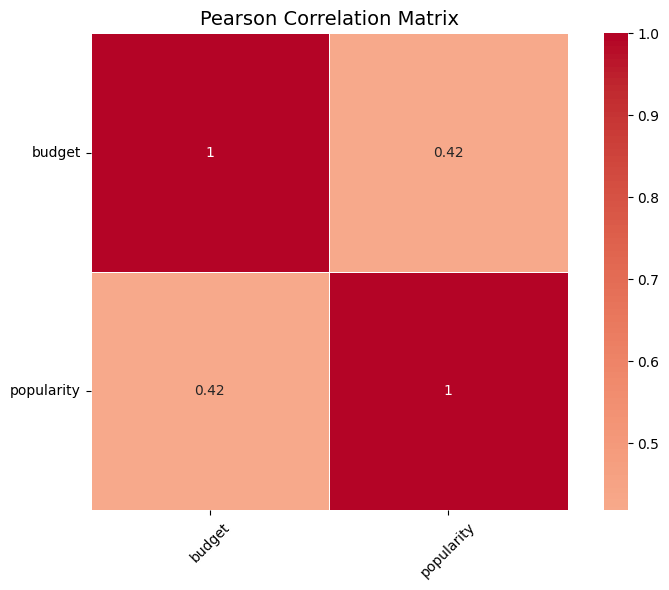

In [184]:
plot_correlation_matrix(df, features=['budget', 'popularity'])

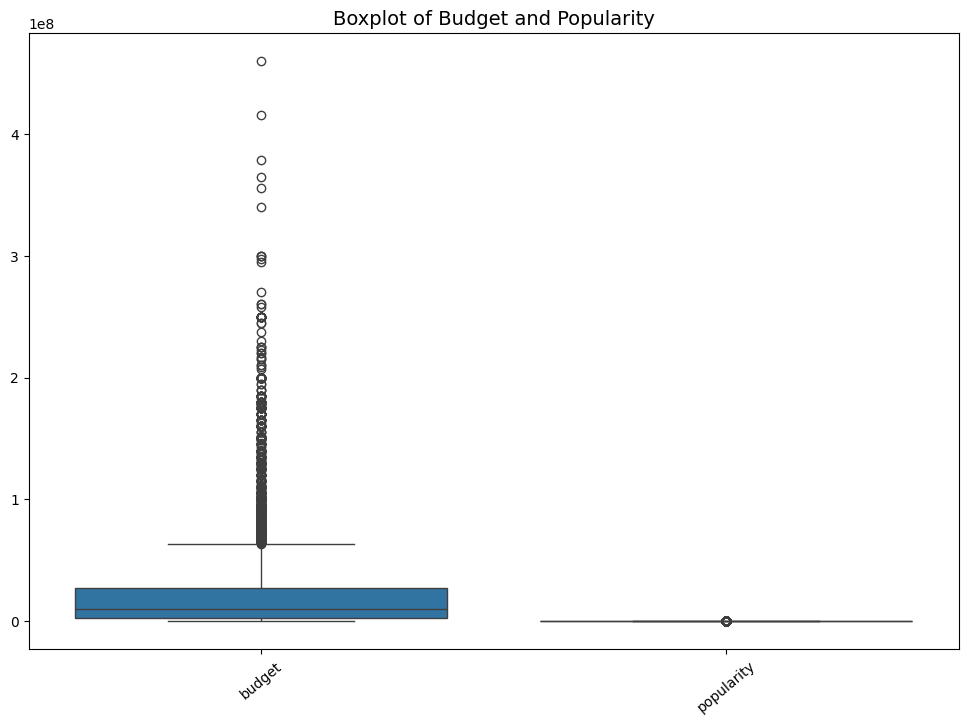

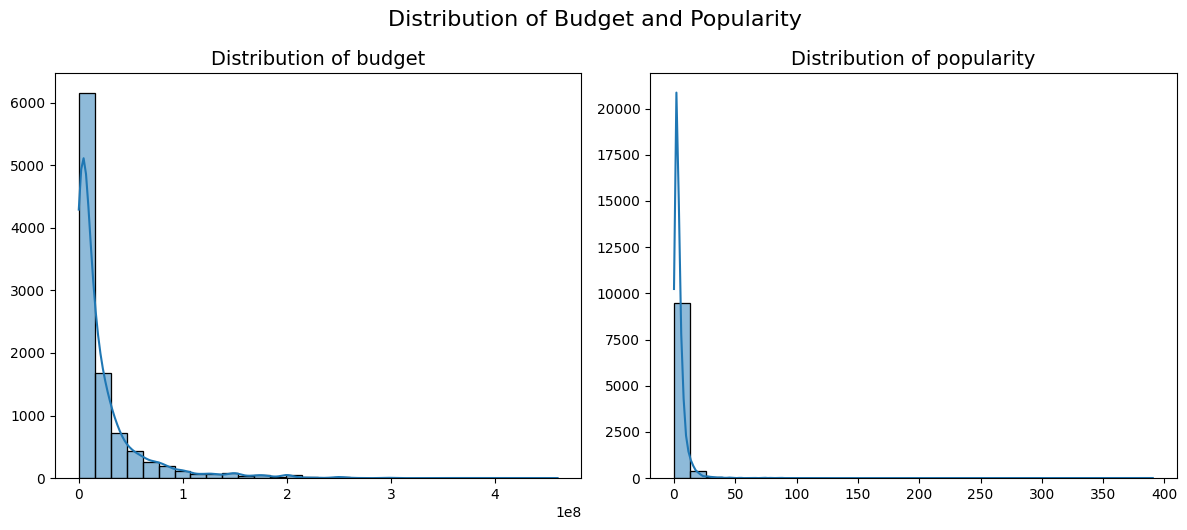

Skewness:
  budget: 3.397
  popularity: 19.615


In [185]:
# Skewness check of the features
plot_boxplot(q1_data, q1_features, title='Boxplot of Budget and Popularity')
plot_feature_distributions(q1_data, q1_features, suptitle='Distribution of Budget and Popularity')

#### 🔁 Log Transformation Decision

Both features are **highly right-skewed** and contain rows with a value of *0*.  
To address this, we apply the **`log1p` transformation** (`log(1 + x)`) to both columns.  
This helps compress large values while safely handling zeros.

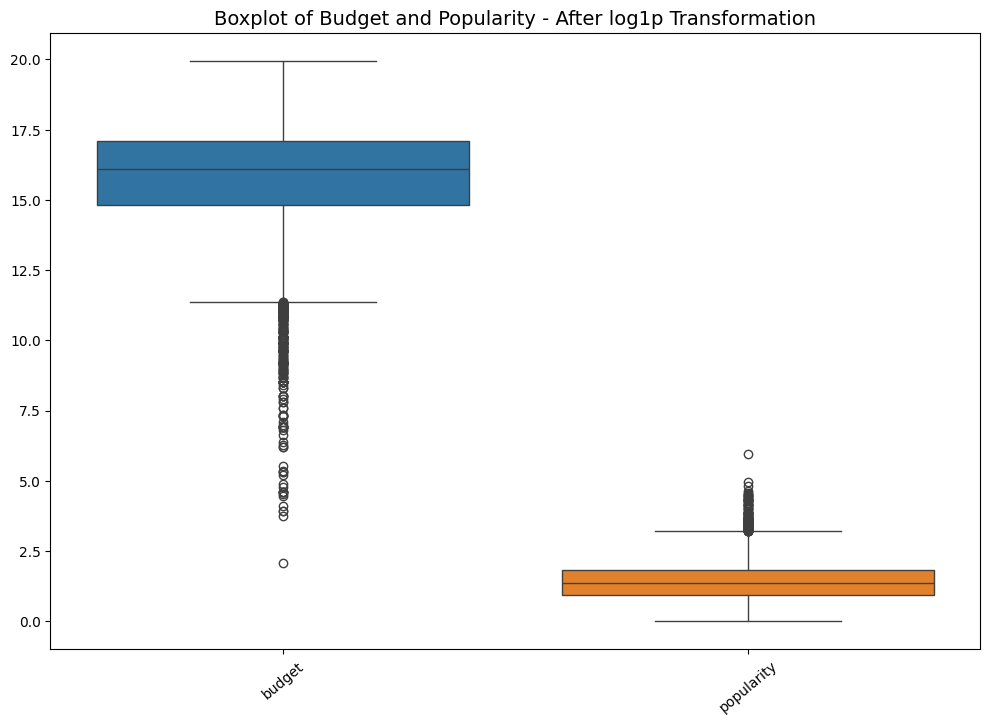

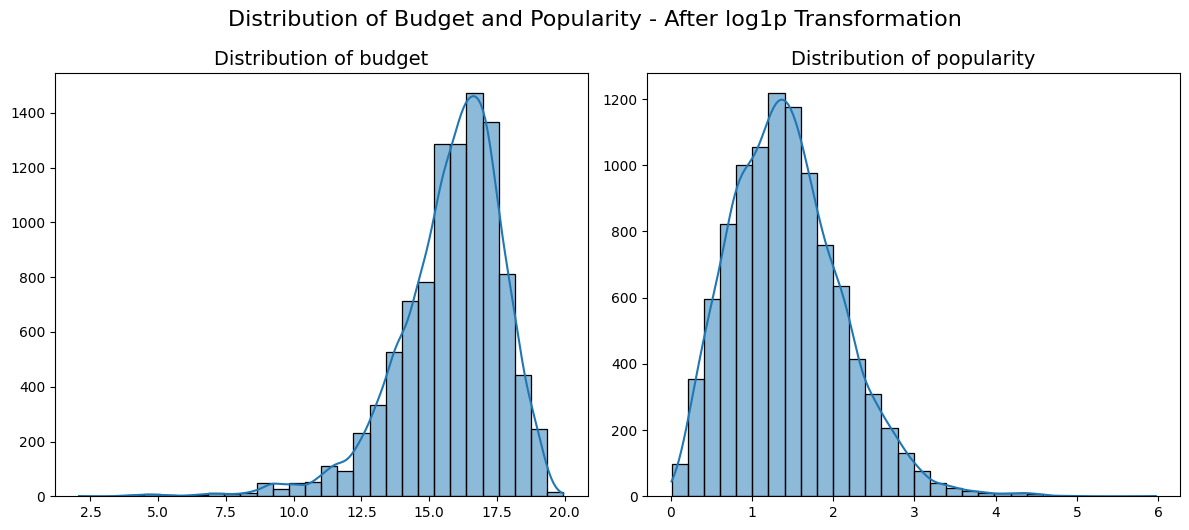

Skewness:
  budget: -1.276
  popularity: 0.668


In [186]:
log1p_transform_column(q1_data, 'budget')
log1p_transform_column(q1_data, 'popularity')

# Skewness check of the features after log1p transformation
plot_boxplot(q1_data, q1_features, title='Boxplot of Budget and Popularity - After log1p Transformation')
plot_feature_distributions(q1_data, q1_features, suptitle='Distribution of Budget and Popularity - After log1p Transformation')

### 📊 Post-Transformation Result

The distributions are not perfectly normal, but they are now **much more balanced and symmetric** compared to the original skewed versions.
___

### 3 - ⚠️ Outlier Removal Methods

To ensure robust clustering results, we test two common outlier detection methods on the `budget` and `popularity` features:

- **Z-Score Method** (threshold = 3)
- **IQR Method** (k = 1.5)

In [187]:
# Outlier removal using Z-score and IQR methods
q1_data_cleanZ = remove_outliers_zscore(q1_data, q1_features)
q1_data_cleanIQR = remove_outliers_iqr(q1_data, q1_features)

In [188]:
# Comparing the number of records before and after outlier removal
print("Number of records before removing outliers:", len(q1_data))
print(f"Number of records after removing outliers using Z-score: {len(q1_data_cleanZ)} ({len(q1_data_cleanZ)/len(q1_data)*100:.2f}% of original)")
print(f"Number of records after removing outliers using IQR: {len(q1_data_cleanIQR)} ({len(q1_data_cleanIQR)/len(q1_data)*100:.2f}% of original)")

Number of records before removing outliers: 9953
Number of records after removing outliers using Z-score: 9727 (97.73% of original)
Number of records after removing outliers using IQR: 9553 (95.98% of original)


In [189]:
q1_data = q1_data_cleanZ

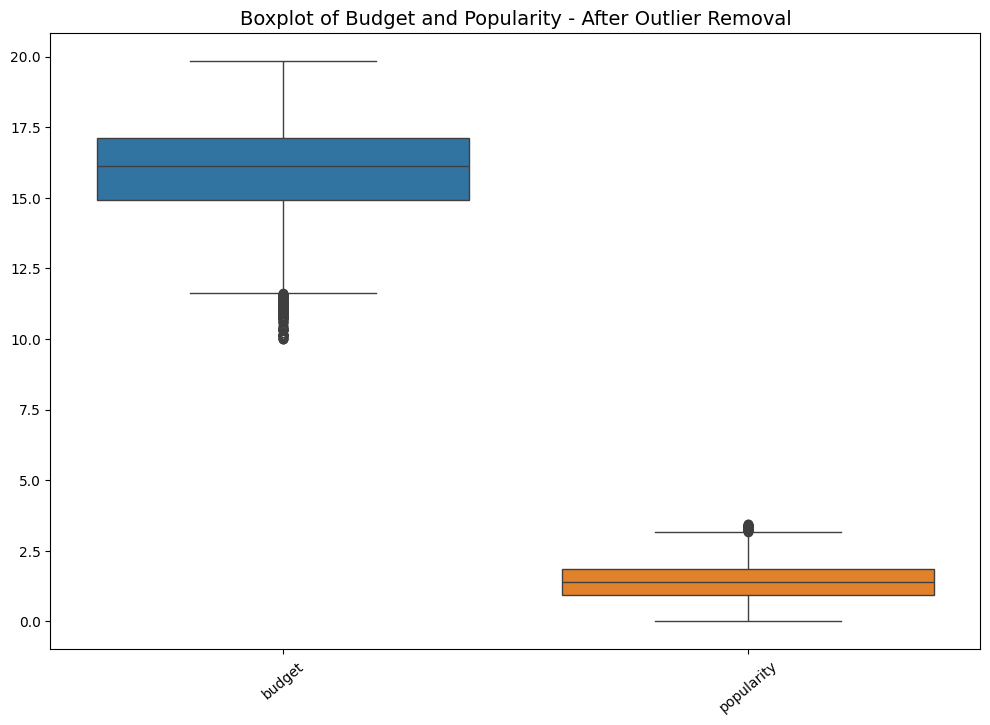

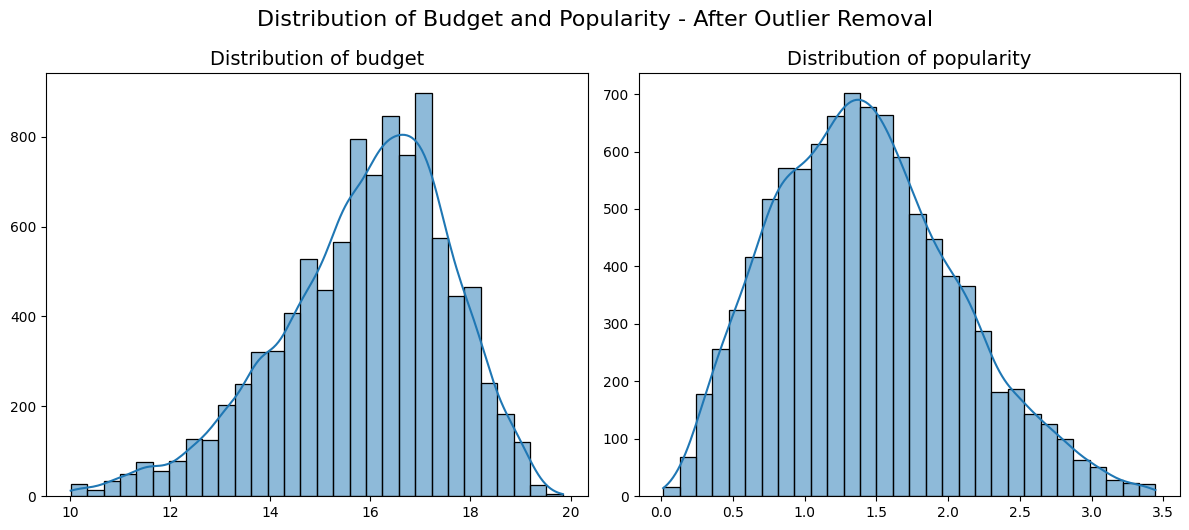

Skewness:
  budget: -0.625
  popularity: 0.399


In [190]:
plot_boxplot(q1_data, q1_features, title='Boxplot of Budget and Popularity - After Outlier Removal')
plot_feature_distributions(q1_data, q1_features, suptitle='Distribution of Budget and Popularity - After Outlier Removal')

### 📊 **Method Selection:**

Since the Z-Score method preserved more data while still filtering extreme values, we chose to proceed with **Z-Score-based outlier removal** for this clustering question.  
This allowed us to minimize data loss while still mitigating the influence of outliers.


___
### 4 - ⚖️ Scaling: Why We Chose StandardScaler

For our question on investment vs. popularity, we used **StandardScaler** because both `budget` and `popularity` are continuous features with **naturally varying scales and distributions**.  
StandardScaler centers the data (mean = 0, std = 1), which is ideal for **distance-based algorithms like K-Means** and helps ensure that no single feature dominates due to its scale.

We avoided MinMaxScaler since it preserves outliers and is more sensitive to extreme values — which we already addressed separately via log transformation and outlier removal.


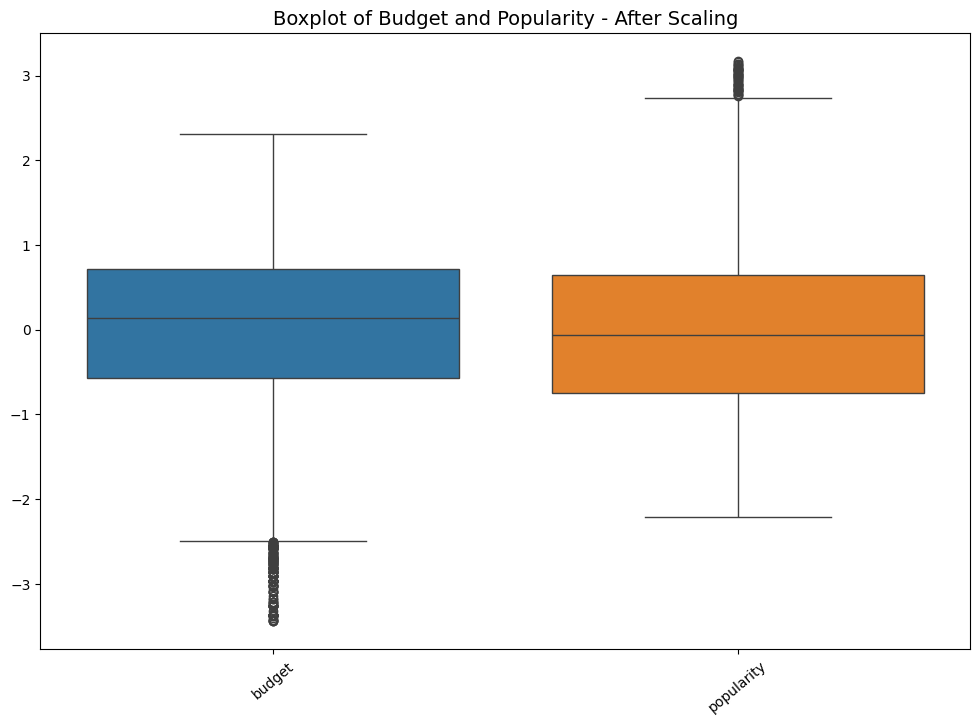

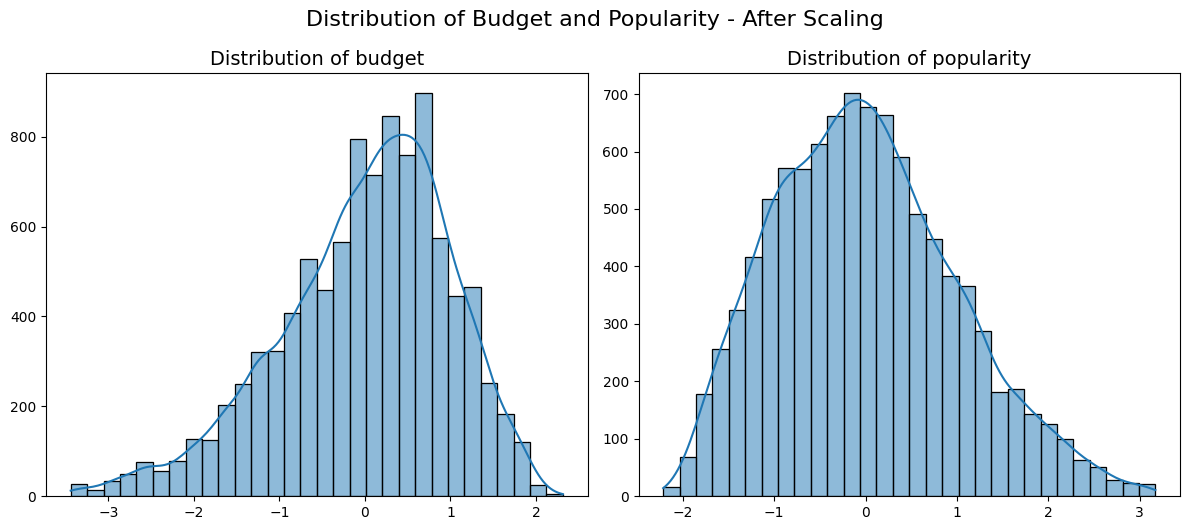

Skewness:
  budget: -0.625
  popularity: 0.399


In [191]:
# Scaling the data
q1_data_scaled = scale_features(q1_data, q1_features, method='standard')

plot_boxplot(q1_data_scaled, q1_features, title='Boxplot of Budget and Popularity - After Scaling')
plot_feature_distributions(q1_data_scaled, q1_features, suptitle='Distribution of Budget and Popularity - After Scaling')

___
### 6 - 🧪 Determining Optimal K

To choose the best value for **K** in K-Means, we use two common evaluation techniques:

#### 🔹 Inertia & Elbow Method
- **Inertia** is the sum of squared distances between each point and its assigned cluster centroid.
- Lower inertia means tighter, more compact clusters.
- Using the **elbow method**, we plot inertia vs. K and look for the point where the rate of decrease sharply slows down — the "elbow." This suggests the optimal tradeoff between model complexity and fit.

#### 🔸 Silhouette Score
- The **silhouette score** measures how similar a point is to its own cluster compared to others.
- It ranges from **-1 to 1**, with higher values indicating well-separated, well-formed clusters.
- We compute the silhouette score for each candidate K to validate the elbow result and ensure cluster quality.


2 clusters — Silhouette Score: 0.4092
3 clusters — Silhouette Score: 0.3762
4 clusters — Silhouette Score: 0.3335
5 clusters — Silhouette Score: 0.3512
6 clusters — Silhouette Score: 0.3278
7 clusters — Silhouette Score: 0.3312


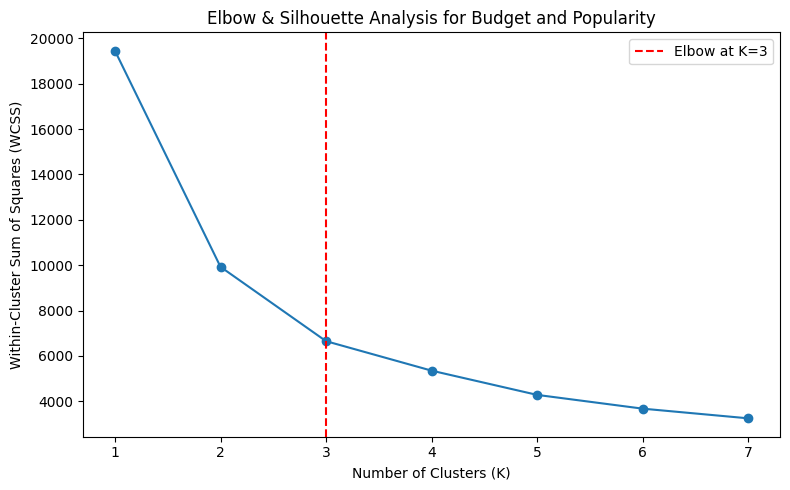

In [192]:
evaluate_kmeans_clustering(q1_data_scaled, k_range=range(1, 8), random_state=42, plot_title='Elbow & Silhouette Analysis for Budget and Popularity')

Silhouette Scores:
  K = 2 → Silhouette Score: 0.4092
  K = 3 → Silhouette Score: 0.3762
  K = 4 → Silhouette Score: 0.3335
  K = 5 → Silhouette Score: 0.3512


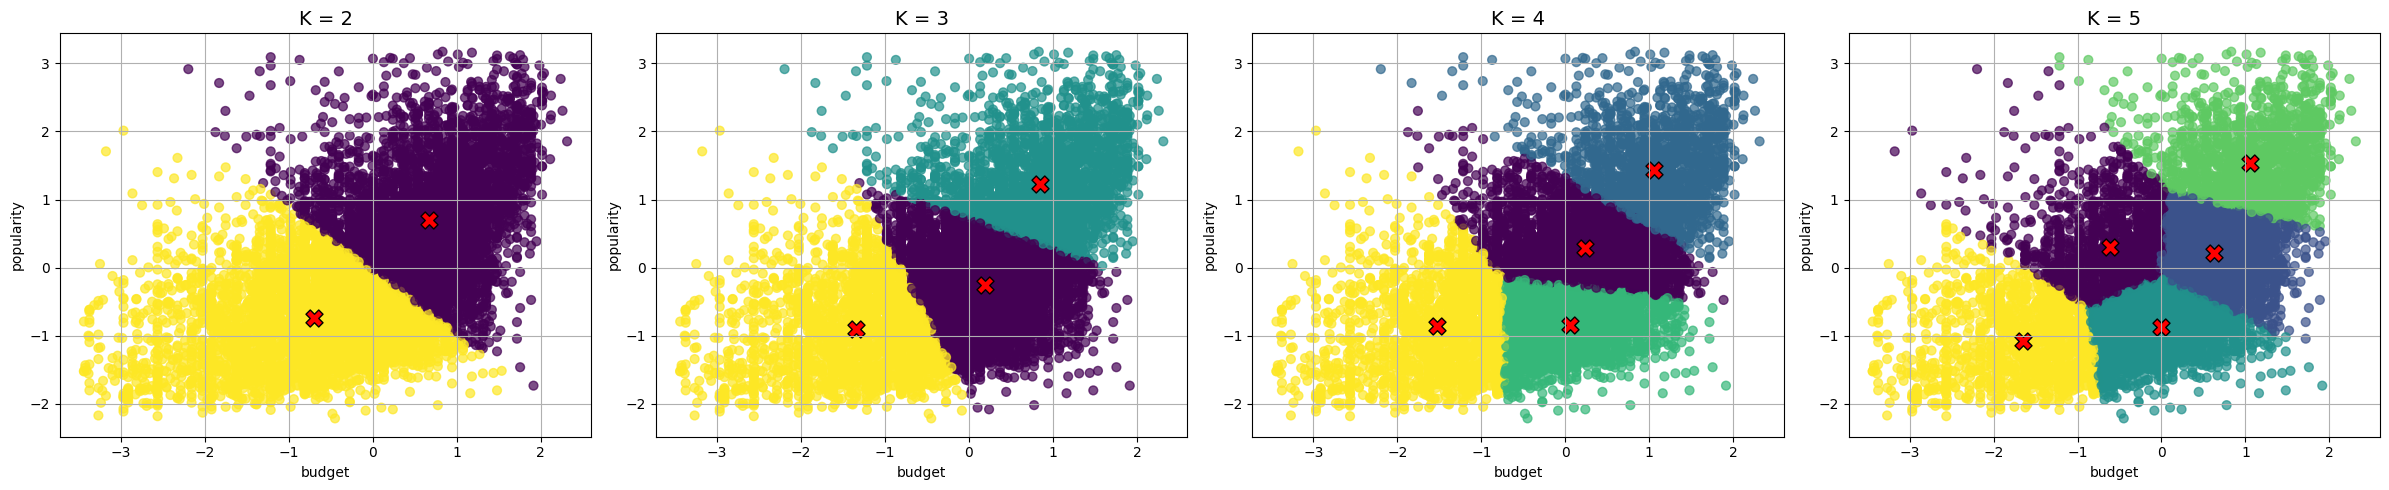

In [193]:
plot_kmeans_clusters_multi_k(q1_data_scaled.values, k_values=range(2, 6), feature_names=q1_features)

### K Selection Results:

#### 📉 Elbow Method
- The Elbow plot shows a sharp drop in **within-cluster sum of squares (WCSS)** from K=1 to K=3.
- After K=3, the rate of improvement decreases significantly.
- Using **KneeLocator**, we identified the elbow at **K=3**, suggesting it as the optimal number of clusters in terms of compactness.

#### 📊 Silhouette Scores
We computed the silhouette score for each K ≥ 2 to assess **how well-separated** and **internally coherent** the clusters are:

| K | Silhouette Score |
|---|------------------|
| 2 | **0.4092**        |
| 3 | 0.3762           |
| 4 | 0.3335           |
| 5 | 0.3512           |
| 6 | 0.3278           |
| 7 | 0.3312           |

- The highest silhouette score is at **K=2**, indicating well-separated clusters.
- However, **K=3** offers a good balance between compactness (WCSS) and separation (silhouette), making it a **justified tradeoff** for richer segmentation.

#### ✅ Conclusion
We chose **K=3** as the final number of clusters for this analysis. It balances interpretability, cluster compactness, and separation — and aligns with the elbow and silhouette trends.
___

### 7 - 🚀 Running K-Means

In [194]:
kmeans_model, labels = fit_kmeans(q1_data_scaled.values, n_clusters=3, random_state=42)

📈 Silhouette Score for K = 3: 0.3762


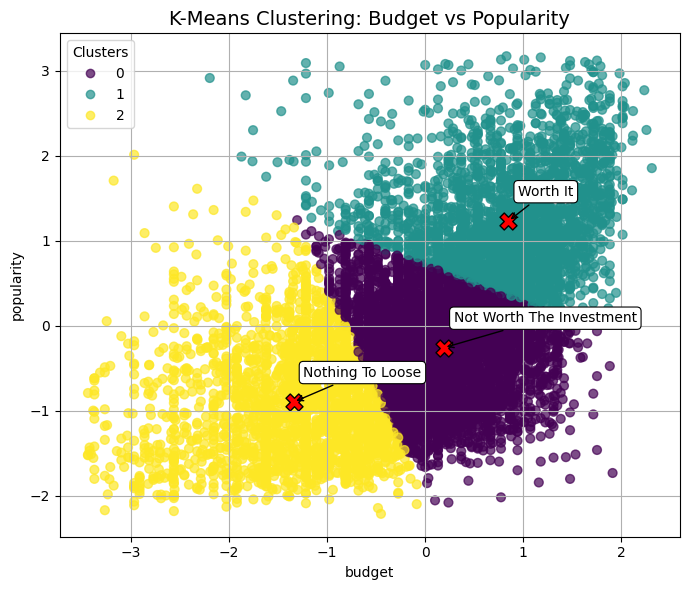

In [195]:
plot_kmeans_with_labels(X=q1_data_scaled.values, kmeans_model=kmeans_model, cluster_labels={0: 'Not Worth The Investment', 1: 'Worth It', 2: 'Nothing To Loose'}, feature_names=q1_features, title='K-Means Clustering: Budget vs Popularity')

### 🎯 Insights from the 2D Scatter Plot

#### 🧠 Key Observations:

- **Cluster 0: “Nothing To Lose”**  
  Low budget films. These are likely small-scale or niche productions that vary in popularity.  
  > ✅ Low risk, but random visibility.

- **Cluster 1: “Not Worth The Investment”**  
  Medium-to-high budget films that failed to gain traction in popularity.  
  > ⚠️ This group suggests poor return on investment — a potential red flag for producers.

- **Cluster 2: “Worth It”**  
  High-budget, high-popularity movies — classic blockbusters.  
  > 💰 These represent successful, widely recognized films that justify their cost.


#### 📈 Model Evaluation:

- **Silhouette Score for K = 3**: `0.3762`  
  This indicates **moderate cluster separation** — the structure is informative but not perfectly distinct.  
  > In real-world social data (like movies), scores between 0.3–0.5 can still reveal valuable patterns.

---

### 8 - 💹 Next Step: Cluster Statistics

Now that we've labeled the clusters based on **visual interpretation**, the next step is to **analyze the defining characteristics of each group**.

We'll examine whether the patterns we observed in the scatter plot are supported by the **underlying feature distributions** within each cluster.

The goal is to validate our initial visual conclusions and see if they align with what the data actually tells us about **budget and popularity dynamics** in each group.

In [196]:
# Adding cluster labels to the original (non-scaled) data
add_cluster_labels(q1_data, labels, label_col='cluster')

# Reverting the log1p transformation for budget and popularity original values
revert_log1p(q1_data, q1_features)

In [197]:
cluster_stats = q1_data.groupby('cluster').agg({
    'budget': ['mean', 'median', 'min', 'max'],
    'popularity': ['mean', 'median', 'min', 'max']
}).round(1)

print("📊 Cluster-wise statistics (based on original values):\n")
cluster_stats

📊 Cluster-wise statistics (based on original values):



budget                                    popularity              \
               mean      median       min          max       mean median  min   
cluster                                                                         
0        16191224.4  10500000.0  858000.0  210000000.0        2.7    2.7  0.1   
1        53359918.7  36000000.0  187000.0  416000000.0        8.9    7.4  3.2   
2         1306543.6   1000000.0   22361.0    6900000.0        1.6    1.2  0.0   

               
          max  
cluster        
0         8.2  
1        30.3  
2        14.0

### Cluster Label Validation: Do the Stats Match the Interpretation?

After labeling the clusters based on the 2D scatter plot of **budget** vs. **popularity**, we now validate whether the **visual assumptions align with the actual feature statistics**.


#### 📊 Cluster 0 → "Not Worth The Investment"
- **Mean budget**: \$16.2M  
- **Mean popularity**: 2.7  
- **Interpretation**: Moderate investment, but relatively low popularity  
- ✅ **Conclusion matches**: These are mid-range productions that underperformed in popularity, making them a questionable investment.

#### 📊 Cluster 1 → "Worth It"
- **Mean budget**: \$53.4M (highest)  
- **Mean popularity**: 8.9 (highest)  
- **Interpretation**: High-budget, high-return blockbusters  
- ✅ **Conclusion matches**: This group clearly reflects successful movies that justified their high cost — the core “hit” cluster.

#### 📊 Cluster 2 → "Nothing To Lose"
- **Mean budget**: \$1.3M (lowest)  
- **Mean popularity**: 1.6 (lowest)  
- **Interpretation**: Very low-budget, low-popularity films — minimal risk, minimal reward  
- ✅ **Conclusion matches**: These are likely indie or micro-budget films with low reach, fitting the “nothing to lose” label.


### 🧠 Final Verdict:
> The statistical summaries support the visual interpretations for each cluster.  
The unsupervised K-Means grouping not only revealed distinct investment/popularity profiles, but also produced clusters that are **intuitively meaningful and data-supported**.  
We can use these clusters for business-based decision making, conclusions and insights.

___

### 1 - 📅 Question B: “Does the season of release affect the success of a movie?”

#### 🎯 Goal:
Investigate whether movies released in different **seasons** show distinct patterns in terms of **success**, such as:
- Summer blockbusters with high revenue and popularity
- Winter releases targeting awards with strong ratings
- Low-performing off-season releases

The aim is to detect **seasonal trends** in movie success — valuable for **marketing strategies**, **release planning**, and **audience targeting**.

#### 📊 Features to Use:
- `season`: Based on release_date (Summer, Winter, Fall, Spring) - Will need to be OHE'd ! (Categorical)
- `revenue`, `weighted_rating`, `popularity`: Success metrics

#### 🔍 Why K-Means Fits:
- Success metrics are **numeric** and naturally suitable for distance-based clustering
- Season (a categorical feature) can be one-hot encoded and **combined with numerical data**
- K-Means can uncover latent seasonal groupings when seasonality co-occurs with success indicators
___

### 2 - 🧹 Data Cleaning

First we will need to one-hot encode our `season` categorical feature so that we can use it in our algorithm.  
Then we will check correlation and skewness of features.

#### 🔢 One-Hot Encoding

One-hot encoding is a technique used to convert **categorical variables** into a numerical format that can be used by machine learning algorithms.

Each category is transformed into a new **boolean column** (True or False), where:
- `True` indicates the presence of that category in a sample,
- `False` indicates its absence.

⚠️ One-hot encoding increases dimensionality, especially with many unique categories, but ensures models do not assume ordinal relationships between category values.


In [198]:
q2 = df.copy()

# One-hot encoding the 'season' categorical feature
season_dummies = pd.get_dummies(q2['season'])

# Adding the one-hot encoded features to the original DataFrame
q2 = pd.concat([q2, season_dummies], axis=1)

# Defining the features for Q2
non_bool_features = ['revenue', 'weighted_rating', 'popularity']
season_features = ['Summer', 'Winter', 'Spring', 'Fall']
q2_features = non_bool_features + season_features

q2_data = q2[q2_features]

In [199]:
q2_data

,revenue,weighted_rating,popularity,Summer,Winter,Spring,Fall
0,4257354,5.915191,6.0785,False,True,False,False
1,12136938,6.430314,3.1484,False,False,False,True
2,775398007,8.194340,49.0688,False,False,True,False
3,940335536,7.808617,19.0085,False,False,True,False
4,677387716,8.460581,26.9118,True,False,False,False
...,...,...,...,...,...,...,...
9948,51749995,5.821839,8.7112,False,False,True,False
9949,78720293,6.250978,5.2863,False,False,True,False
9950,850000,6.092949,0.4441,False,False,True,False
9951,10000,6.179887,0.4584,False,True,False,False


In [200]:
# Converting True/False columns to 1/0 integers
q2_data = q2_data.astype({col: int for col in q2_data.select_dtypes(include='bool').columns})

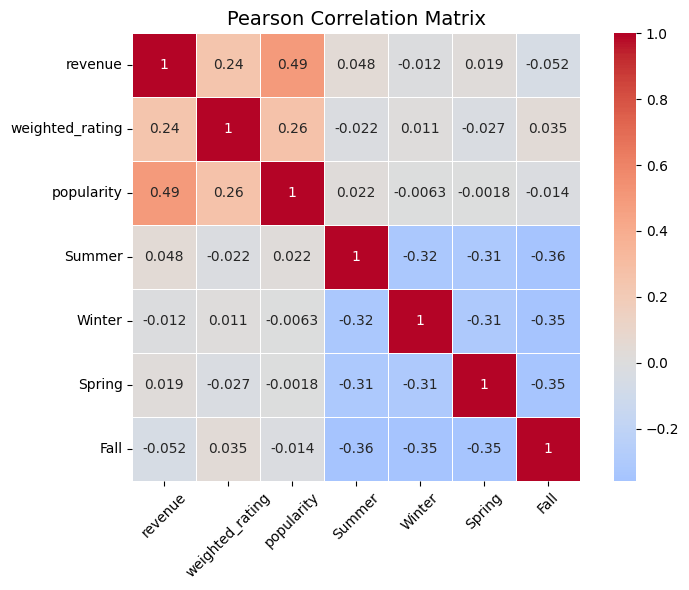

In [201]:
# Correlation check of the features
plot_correlation_matrix(q2_data, features=q2_features)

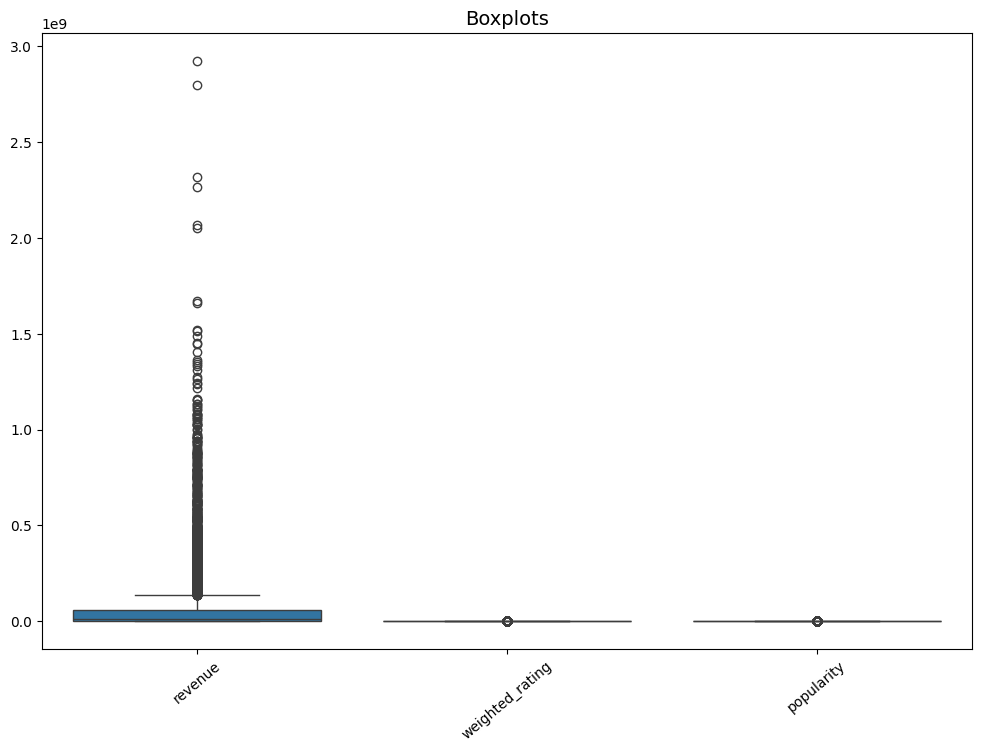

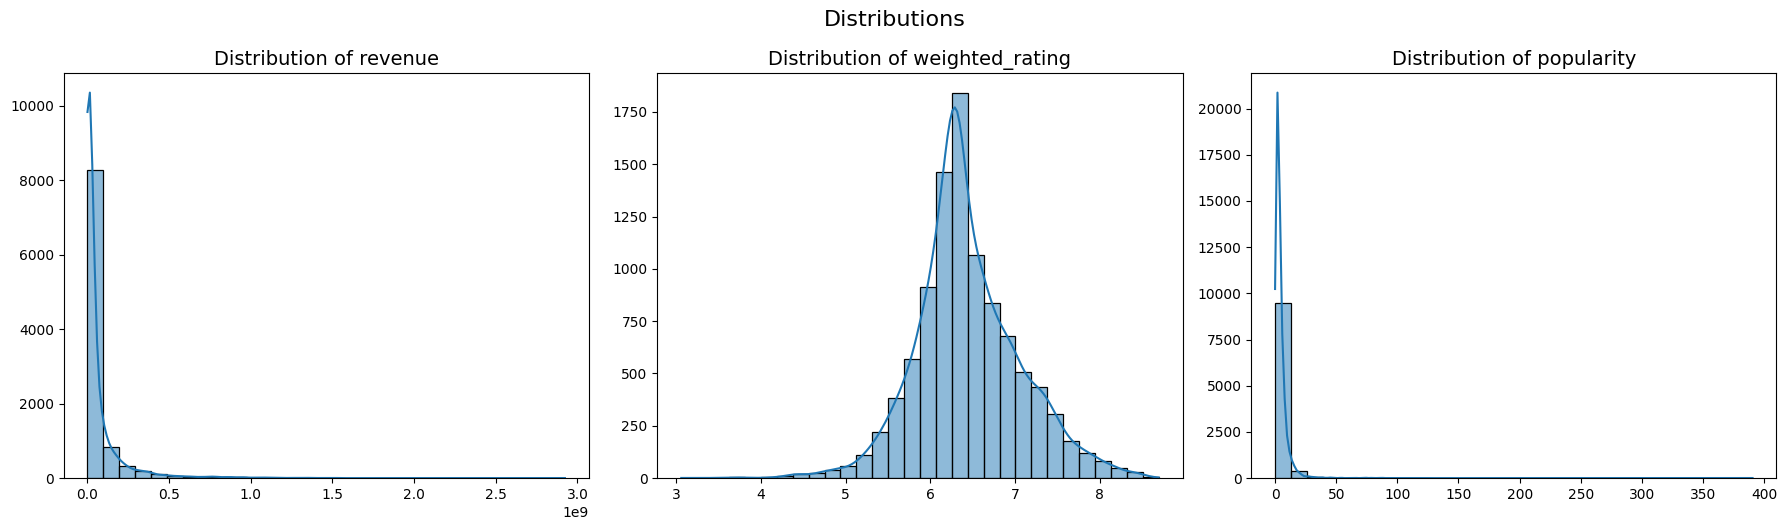

Skewness:
  revenue: 6.019
  weighted_rating: 0.218
  popularity: 19.615


In [202]:
# Skewness check of the features
plot_boxplot(q2_data, non_bool_features, title='Boxplots')
plot_feature_distributions(q2_data, non_bool_features, suptitle='Distributions')

#### 🔁 Log Transformation Decision

Two of the features are **highly right-skewed** and contain rows with a value of *0*.  
To address this, we apply the **`log1p` transformation** (`log(1 + x)`) to both columns.  
This helps compress large values while safely handling zeros.

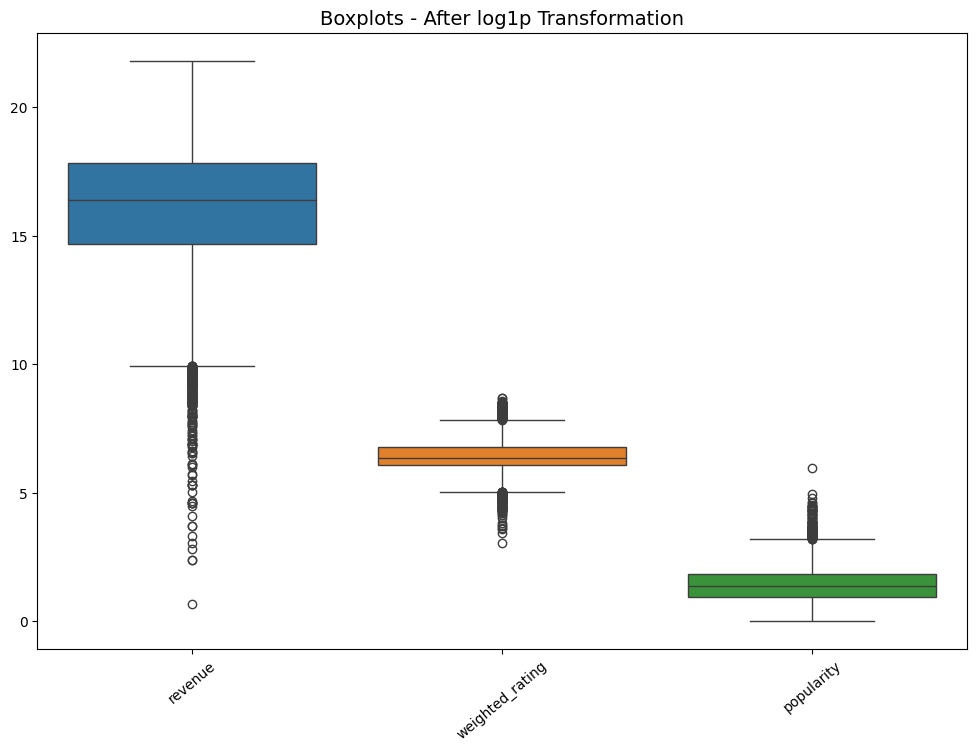

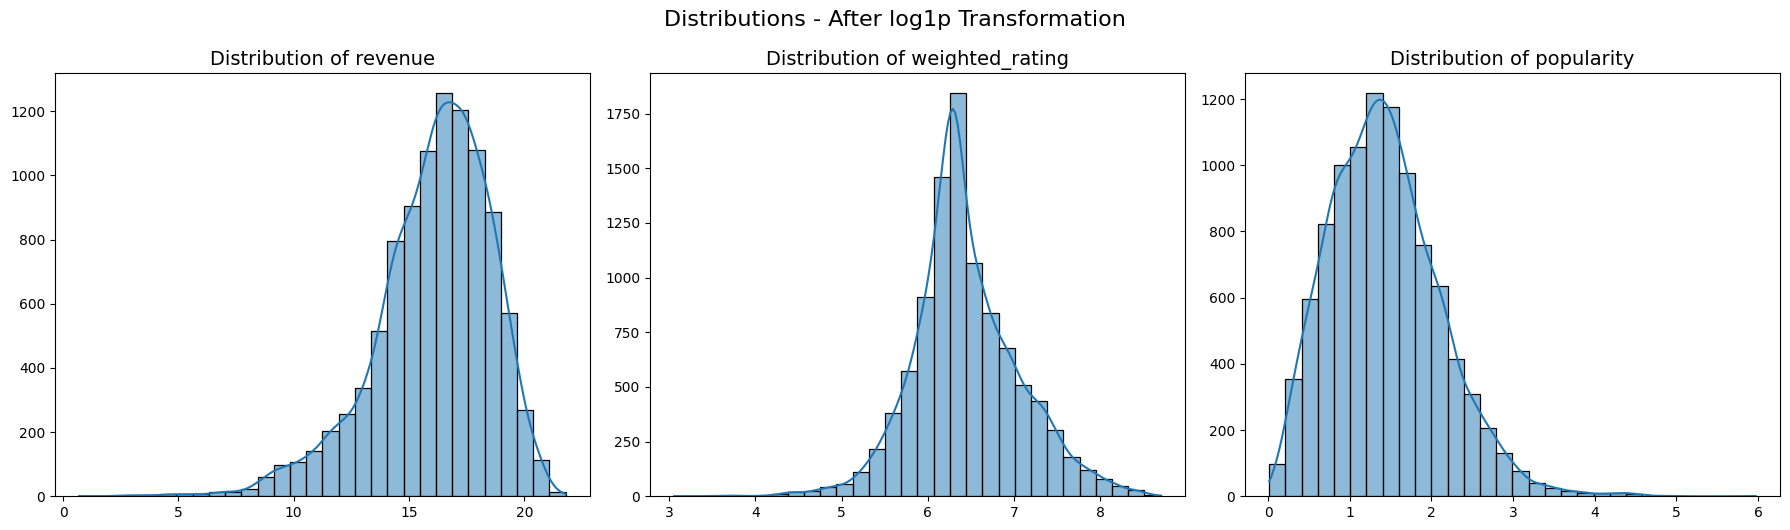

Skewness:
  revenue: -0.933
  weighted_rating: 0.218
  popularity: 0.668


In [203]:
log1p_transform_column(q2_data, 'revenue')
log1p_transform_column(q2_data, 'popularity')

# Skewness check of the features after log1p transformation
plot_boxplot(q2_data, non_bool_features, title='Boxplots - After log1p Transformation')
plot_feature_distributions(q2_data, non_bool_features, suptitle='Distributions - After log1p Transformation')

In [204]:
q2_data

,revenue,weighted_rating,popularity,Summer,Winter,Spring,Fall
0,15.264159,5.915191,1.957062,0,1,0,0
1,16.311764,6.430314,1.422723,0,0,0,1
2,20.468887,8.194340,3.913398,0,0,1,0
3,20.661747,7.808617,2.996157,0,0,1,0
4,20.333754,8.460581,3.329050,1,0,0,0
...,...,...,...,...,...,...,...
9948,17.761935,5.821839,2.273280,0,0,1,0
9949,18.181412,6.250978,1.838373,0,0,1,0
9950,13.652993,6.092949,0.367486,0,0,1,0
9951,9.210440,6.179887,0.377340,0,1,0,0


### 3 - ⚠️ Outlier Removal Methods

To ensure robust clustering results, we test two common outlier detection methods on the features:

- **Z-Score Method** (threshold = 3)
- **IQR Method** (k = 1.5)

In [205]:
# Outlier removal using Z-score and IQR methods
q2_data_cleanZ = remove_outliers_zscore(q2_data, non_bool_features)
q2_data_cleanIQR = remove_outliers_iqr(q2_data, non_bool_features)

In [206]:
# Comparing the number of records before and after outlier removal
print("Number of records before removing outliers:", len(q2_data))
print(f"Number of records after removing outliers using Z-score: {len(q2_data_cleanZ)} ({len(q2_data_cleanZ)/len(q2_data)*100:.2f}% of original)")
print(f"Number of records after removing outliers using IQR: {len(q2_data_cleanIQR)} ({len(q2_data_cleanIQR)/len(q2_data)*100:.2f}% of original)")

Number of records before removing outliers: 9953
Number of records after removing outliers using Z-score: 9725 (97.71% of original)
Number of records after removing outliers using IQR: 9297 (93.41% of original)


In [207]:
q2_data = q2_data_cleanIQR

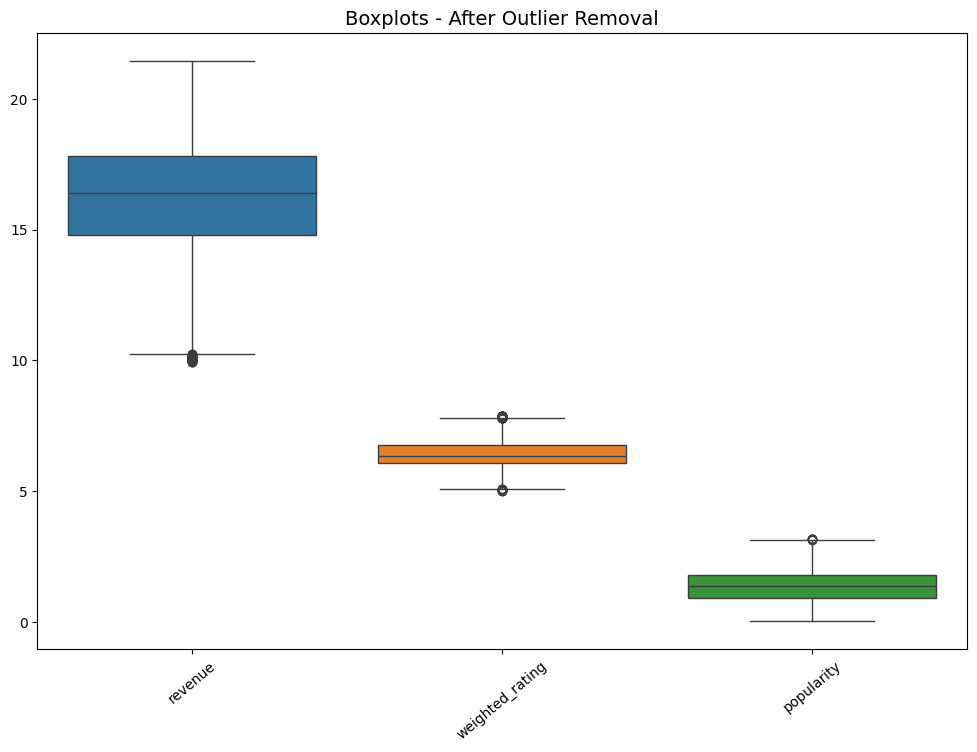

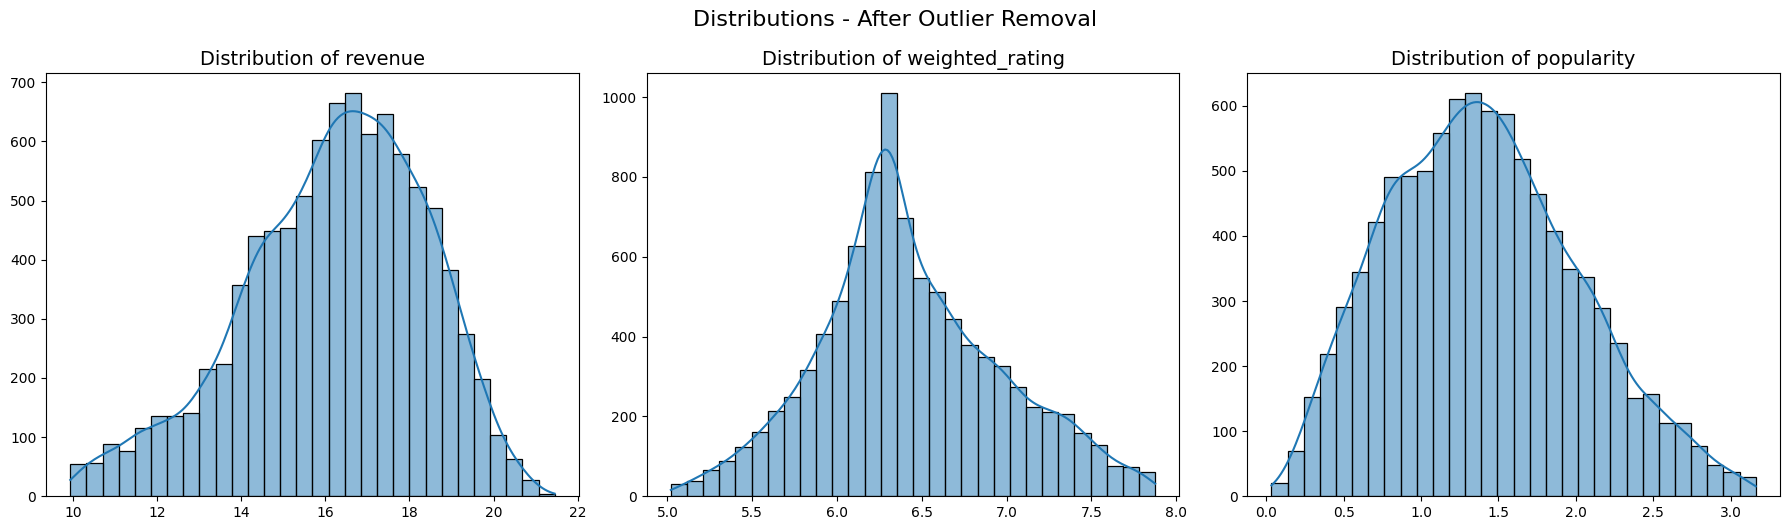

Skewness:
  revenue: -0.462
  weighted_rating: 0.269
  popularity: 0.307


In [208]:
plot_boxplot(q2_data, non_bool_features, title='Boxplots - After Outlier Removal')
plot_feature_distributions(q2_data, non_bool_features, suptitle='Distributions - After Outlier Removal')

### 📊 **Method Selection:**

This time we have decided to proceed with the IQR method of removing outliers for this clustering question.  
This removes a more large range of outliers and keeps the distibutions as equal as possible.

___
### 4 - ⚖️ Scaling: Why We Chose StandardScaler

For our question previous question we used **StandardScaler** because both `budget` and `popularity` are continuous features with **naturally varying scales and distributions**.  
This time we decided to use MinMaxScaler since we don't have any negative values and have a smaller range, so compacting them from a range of 0 - 1 seems more robust to our needs.


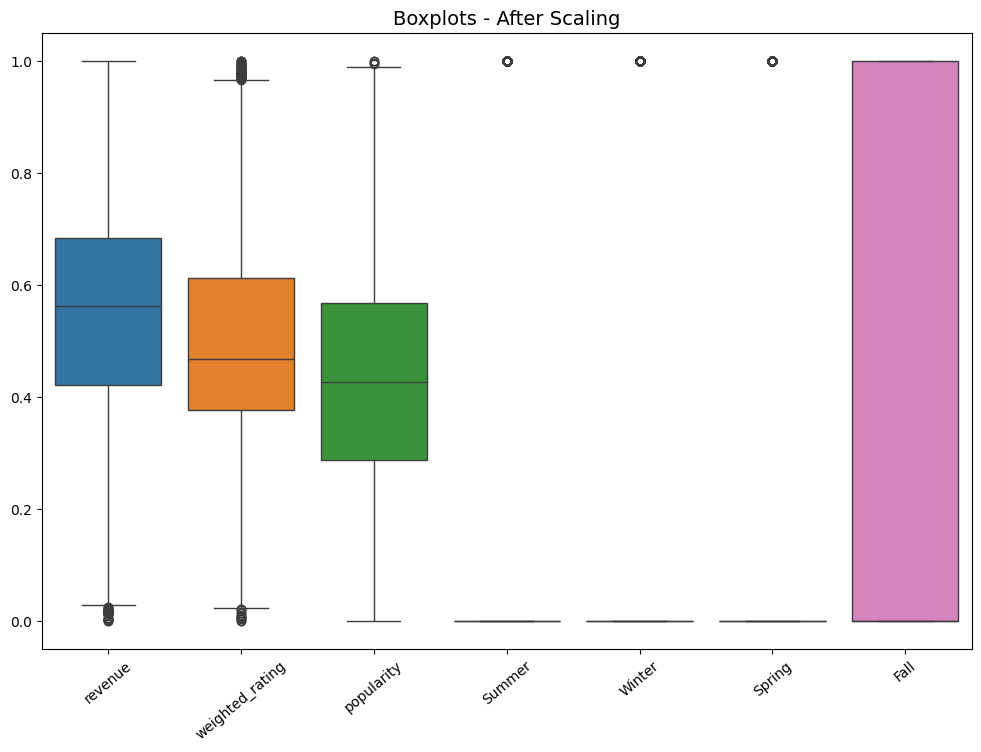

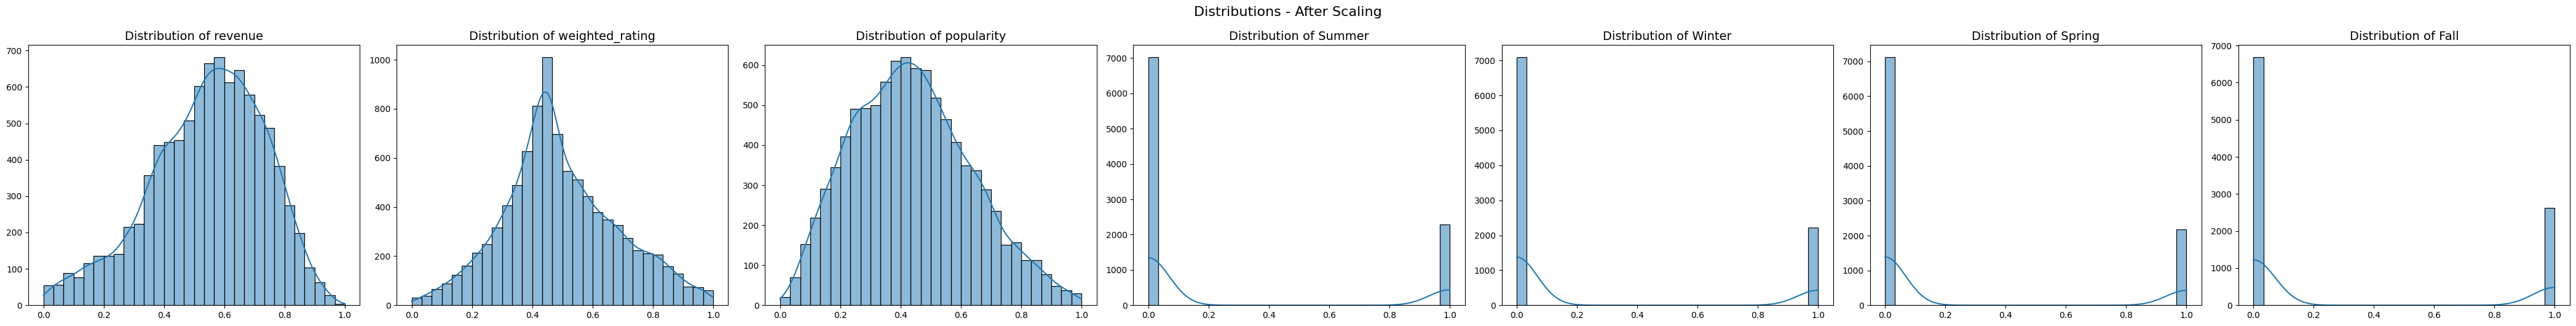

Skewness:
  revenue: -0.462
  weighted_rating: 0.269
  popularity: 0.307
  Summer: 1.184
  Winter: 1.229
  Spring: 1.250
  Fall: 0.972


In [209]:
# Scaling the data
q2_data_scaled = scale_features(q2_data, q2_features, method='minmax')

plot_boxplot(q2_data_scaled, q2_features, title='Boxplots - After Scaling')
plot_feature_distributions(q2_data_scaled, q2_features, suptitle='Distributions - After Scaling')

### 6. 📏 Dimensionality Reduction

#### 🧬 Principal Component Analysis (PCA)

**Principal Component Analysis (PCA)** is a **dimensionality reduction** technique used to simplify complex datasets while preserving their most important structures.

##### 🎯 Why Use PCA?

- Reduce the number of features while retaining the **maximum amount of variance** (information).
- Eliminate **multicollinearity** between features.
- Improve **visualization** in 2D or 3D.
- Enhance performance for algorithms sensitive to high dimensionality.

---

##### 📌 Key Concepts

- **Principal Components**: New axes that are **linear combinations** of the original features.
- **PC1, PC2, PC3…**: Ordered by the amount of **variance** they capture.
- **Explained Variance Ratio**: Measures how much information each component retains.

---

##### ⚠️ When to Use with Caution

- PCA is **unsupervised**: it ignores target labels.
- It creates **new, abstract features**, which can reduce interpretability.
- It assumes **linear relationships** and may not capture nonlinear patterns.

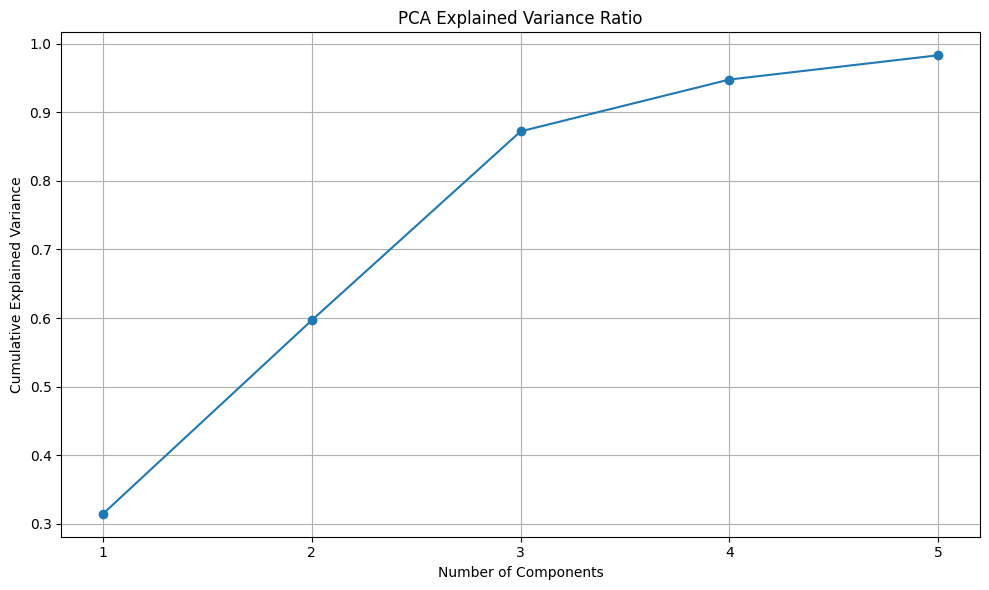

In [210]:
plot_pca_explained_variance(q2_data_scaled, max_components=5, figsize=(10, 6), step=1)

> Using 3 principal components preserves nearly **90% of the original variance**, maintaining a strong representation of the data's structure.  
This allows for accurate **3D visualization** while keeping proportions closely aligned with the original high-dimensional space.

In [211]:
pca, scores_pca = apply_pca(q2_data_scaled, n_components=3)

___
### 6 - 🧪 Determining Optimal K
**After** reducing to 3 principal components, we apply K-Means with numerous K's to check both inertia and silhouette scores:

2 clusters — Silhouette Score: 0.5162
3 clusters — Silhouette Score: 0.7554
4 clusters — Silhouette Score: 0.9905
5 clusters — Silhouette Score: 0.8650
6 clusters — Silhouette Score: 0.7403
7 clusters — Silhouette Score: 0.5883


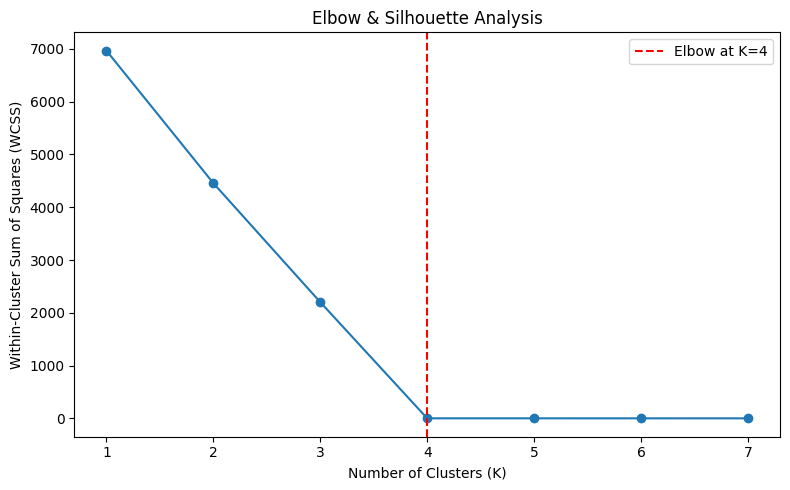

In [212]:
evaluate_kmeans_clustering(scores_pca, k_range=range(1, 8), random_state=42, plot_title='Elbow & Silhouette Analysis')

> We can see a very clear eblow break at K = 4.  
We will fit our model with this K

### 7 - 🚀 Running K-Means

In [213]:
kmeans_model, labels = fit_kmeans(scores_pca, n_clusters=4, random_state=42)

In [214]:
plot_pca_3d(scores_pca, labels, pca.components_, feature_names=q2_features, title='3D PCA Projection')

#### 🔍 Observations from the Plot

##### 👀 What We See:
- We observe **4 clearly distinct clusters**, each well-separated in space.
- These clusters align almost perfectly with the **seasons** (e.g., Winter, Spring, etc.).
- The contribution of **non-seasonal features** appears to have minimal influence on the spatial distribution of data points.

---

##### 🧠 What We Learn:
- Using **boolean/binary features** (like seasons) in distance-based clustering and mapping can **heavily distort the results**.
- The clustering is dominated by seasonal labels, offering **little to no insight** beyond what we already knew.
- As a result, this clustering fails to reveal deeper patterns beyond seasonal separation.

---

##### 🛠️ What We Can Do:
- ❌ **Remove the seasonal features** and re-cluster using only the remaining variables to uncover intrinsic structure — but this may compromise our original research question.  
To counter this we can use a **subplot approach**: While not precise per season, it offers a general visual impression of how each seasonal cluster behaves across other features.
- 🔄 **Split the dataset** into four seasonal subsets and visualize them independently to explore feature behavior **within** each season.

---

##### ✅ Chosen Strategy:
We will proceed with the **second approach**:


In [215]:
# Splitting the dataset into seasonal subsets for visualization
winter = q2_data_scaled[q2_data_scaled['Winter'] == 1].drop(columns=['Winter', 'Spring', 'Summer', 'Fall'])
summer = q2_data_scaled[q2_data_scaled['Summer'] == 1].drop(columns=['Winter', 'Spring', 'Summer', 'Fall'])
spring = q2_data_scaled[q2_data_scaled['Spring'] == 1].drop(columns=['Winter', 'Spring', 'Summer', 'Fall'])
fall = q2_data_scaled[q2_data_scaled['Fall'] == 1].drop(columns=['Winter', 'Spring', 'Summer', 'Fall'])

💡 **Retrospective Insight**: Both the **inertia** and **silhouette score** are nearly identical across all seasons, indicating that the clustering structure is consistent regardless of season.
> Although the automated elbow plot suggests an elbow at **K = 3**, a manual inspection reveals a **sharper elbow at K = 2**.  
Combined with the fact that **K = 2 yields the highest silhouette score**, we selected **K = 2** for the clustering in the following models.

2 clusters — Silhouette Score: 0.3470
3 clusters — Silhouette Score: 0.2956
4 clusters — Silhouette Score: 0.2775
5 clusters — Silhouette Score: 0.2704
6 clusters — Silhouette Score: 0.2562
7 clusters — Silhouette Score: 0.2596


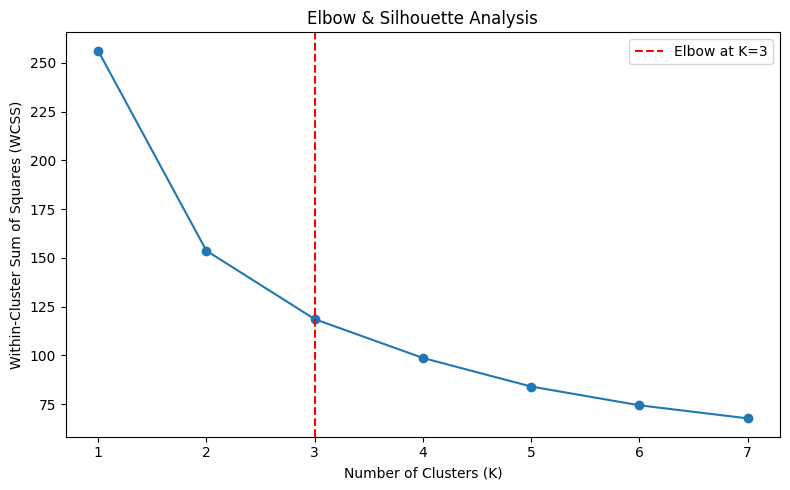

📊 Cluster-wise statistics - Summer:


revenue                  weighted_rating                  popularity  \
           mean median  min  max            mean median  min  max       mean   
cluster                                                                        
0           1.0    1.1  0.3  1.7             0.6    0.6  0.0  1.0        0.9   
1           0.6    0.6  0.0  1.3             0.4    0.4  0.0  0.9        0.4   

                          
        median  min  max  
cluster                   
0          0.9  0.2  1.7  
1          0.4  0.0  1.0

In [216]:
# Summer season

# Testing different K values for K-Means clustering
evaluate_kmeans_clustering(summer, k_range=range(1, 8), random_state=42, plot_title='Elbow & Silhouette Analysis')

# Fitting K-Means with 2 clusters
kmeans_modelSU, labelsSU = fit_kmeans(summer, n_clusters=2)

# Plotting the clusters in 3D
plot_3d(summer, x_col='revenue', y_col='weighted_rating', z_col='popularity', color_col=labelsSU, title='3D Scatter Plot - Summer Clusters')

# Adding cluster labels to the original (non-scaled) data
add_cluster_labels(summer, labelsSU, label_col='cluster')

# Reverting the log1p transformation for revenue and popularity original values
revert_log1p(summer, ['revenue', 'popularity'])

# Cluster-wise statistics
cluster_statsSU = summer.groupby('cluster').agg({
    'revenue': ['mean', 'median', 'min', 'max'],
    'weighted_rating': ['mean', 'median', 'min', 'max'],
    'popularity': ['mean', 'median', 'min', 'max']
}).round(1)

print("📊 Cluster-wise statistics - Summer:")
display(cluster_statsSU)

2 clusters — Silhouette Score: 0.3374
3 clusters — Silhouette Score: 0.3030
4 clusters — Silhouette Score: 0.2899
5 clusters — Silhouette Score: 0.2672
6 clusters — Silhouette Score: 0.2520
7 clusters — Silhouette Score: 0.2641


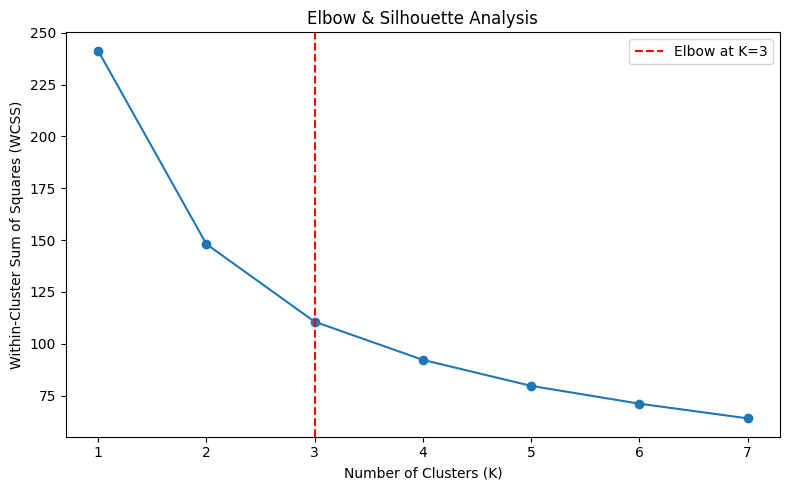


📊 Cluster-wise statistics - Winter:


revenue                  weighted_rating                  popularity  \
           mean median  min  max            mean median  min  max       mean   
cluster                                                                        
0           1.0    1.0  0.1  1.7             0.6    0.6  0.0  1.0        0.8   
1           0.6    0.6  0.0  1.4             0.4    0.4  0.0  0.8        0.4   

                          
        median  min  max  
cluster                   
0          0.8  0.3  1.7  
1          0.4  0.0  1.0

In [217]:
# Winter season
evaluate_kmeans_clustering(winter, k_range=range(1, 8), random_state=42, plot_title='Elbow & Silhouette Analysis')

kmeans_modelWI, labelsWI = fit_kmeans(winter, n_clusters=2)

plot_3d(winter, x_col='revenue', y_col='weighted_rating', z_col='popularity', color_col=labelsWI, title='3D Scatter Plot - Winter Clusters')

add_cluster_labels(winter, labelsWI, label_col='cluster')

revert_log1p(winter, ['revenue', 'popularity'])

cluster_statsWI = winter.groupby('cluster').agg({
    'revenue': ['mean', 'median', 'min', 'max'],
    'weighted_rating': ['mean', 'median', 'min', 'max'],
    'popularity': ['mean', 'median', 'min', 'max']
}).round(1)

print("\n📊 Cluster-wise statistics - Winter:")
display(cluster_statsWI)

2 clusters — Silhouette Score: 0.3376
3 clusters — Silhouette Score: 0.2852
4 clusters — Silhouette Score: 0.2871
5 clusters — Silhouette Score: 0.2654
6 clusters — Silhouette Score: 0.2740
7 clusters — Silhouette Score: 0.2590


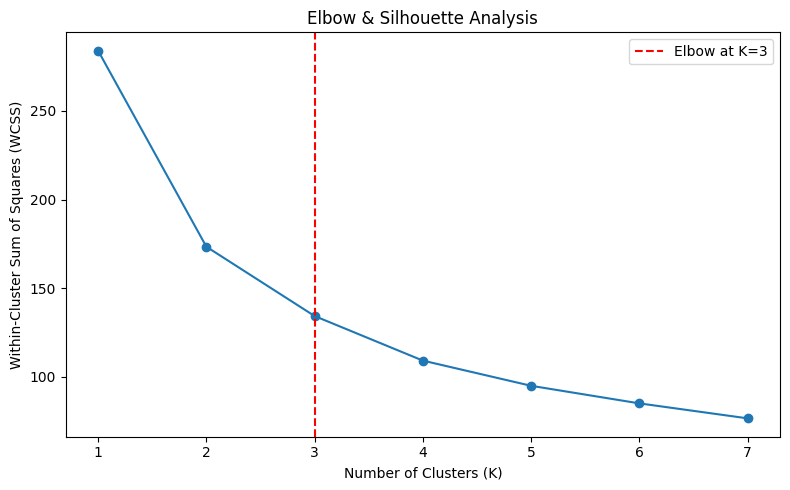


📊 Cluster-wise statistics - Fall:


revenue                  weighted_rating                  popularity  \
           mean median  min  max            mean median  min  max       mean   
cluster                                                                        
0           1.0    1.0  0.2  1.6             0.6    0.7  0.1  1.0        0.8   
1           0.6    0.6  0.0  1.3             0.4    0.4  0.0  0.9        0.4   

                          
        median  min  max  
cluster                   
0          0.8  0.2  1.7  
1          0.4  0.0  1.0

In [218]:
# Fall season
evaluate_kmeans_clustering(fall, k_range=range(1, 8), random_state=42, plot_title='Elbow & Silhouette Analysis')

kmeans_modelFA, labelsFA = fit_kmeans(fall, n_clusters=2)

plot_3d(fall, x_col='revenue', y_col='weighted_rating', z_col='popularity', color_col=labelsFA, title='3D Scatter Plot - Fall Clusters')

add_cluster_labels(fall, labelsFA, label_col='cluster')

revert_log1p(fall, ['revenue', 'popularity'])

cluster_statsFA = fall.groupby('cluster').agg({
    'revenue': ['mean', 'median', 'min', 'max'],
    'weighted_rating': ['mean', 'median', 'min', 'max'],
    'popularity': ['mean', 'median', 'min', 'max']
}).round(1)

print("\n📊 Cluster-wise statistics - Fall:")
display(cluster_statsFA)

2 clusters — Silhouette Score: 0.3405
3 clusters — Silhouette Score: 0.2845
4 clusters — Silhouette Score: 0.3029
5 clusters — Silhouette Score: 0.2767
6 clusters — Silhouette Score: 0.2584
7 clusters — Silhouette Score: 0.2535


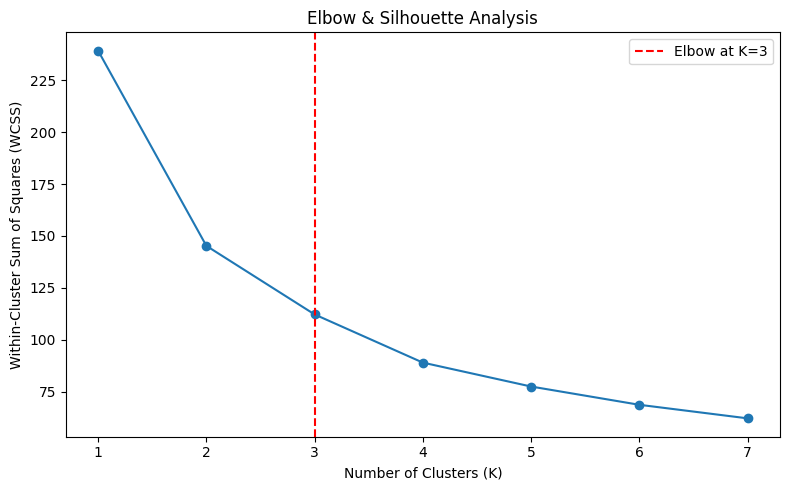


📊 Cluster-wise statistics - Spring:


revenue                  weighted_rating                  popularity  \
           mean median  min  max            mean median  min  max       mean   
cluster                                                                        
0           0.6    0.6  0.0  1.4             0.4    0.4  0.0  1.0        0.4   
1           1.0    1.0  0.3  1.6             0.6    0.6  0.0  1.0        0.9   

                          
        median  min  max  
cluster                   
0          0.4  0.0  0.9  
1          0.8  0.1  1.7

In [219]:
# Spring season
evaluate_kmeans_clustering(spring, k_range=range(1, 8), random_state=42, plot_title='Elbow & Silhouette Analysis')

kmeans_modelSP, labelsSP = fit_kmeans(spring, n_clusters=2)

plot_3d(spring, x_col='revenue', y_col='weighted_rating', z_col='popularity', color_col=labelsSP, title='3D Scatter Plot - Spring Clusters')

add_cluster_labels(spring, labelsSP, label_col='cluster')

revert_log1p(spring, ['revenue', 'popularity'])

cluster_statsSP = spring.groupby('cluster').agg({
    'revenue': ['mean', 'median', 'min', 'max'],
    'weighted_rating': ['mean', 'median', 'min', 'max'],
    'popularity': ['mean', 'median', 'min', 'max']
}).round(1)

print("\n📊 Cluster-wise statistics - Spring:")
display(cluster_statsSP)

#### 🌸 Seasonal Clustering Analysis

##### 📊 3D Cluster Visualization

The 3D scatter plot shows two clearly separated clusters within the subsets, based on the following normalized features:
- `revenue`
- `weighted_rating`
- `popularity`

The two clusters are:
- **Visually distinct** — mostly separated along the `revenue` and `popularity` axes.
- **Consistently shaped and distributed**.

---

##### 📈 Cluster-Wise Statistics Summary

Key insights:
- **Cluster 1** consistently outperforms **Cluster 0** across all metrics: it contains **higher-rated**, **more popular**, and **more profitable** movies.
- **Cluster 0**, while also having high variance (e.g., revenue ranging from 0 to 1.4), appears to be more concentrated in the **low-to-mid range** on all three dimensions.

This statistical structure is **mirrored in all four seasonal subsets**, showing near-identical cluster shapes and distributions.

---

##### 🧠 Conclusions

- 💡 **The same cluster pattern repeats across all seasons**, suggesting that **seasonality is not a primary differentiator** for the success or profile of a movie once the seasonal feature is removed.
- 🔄 Each season reveals a **structure**:
  - One group contains **high-performing movies** (Cluster 1).
  - The other includes more **average or low-performing movies** (Cluster 0).
- 📌 This indicates that regardless of season, movies **naturally divide** into two dominant performance-based groups.
- 📊 The 3D plots together reveal that **season only influences separation when included explicitly as a binary variable** — once filtered out, the **underlying structure remains stable**.

---

##### ✅ Final Takeaway

Clustering by season doesn’t uncover season-specific movie types or behaviors — instead, it **repeats the same success-based segmentation**. This suggests that:
> 🎬 **Movie performance clusters are independent of seasonal release** — and more driven by intrinsic content and reception metrics like `popularity`, `revenue`, and `rating`.

___

#### 🌐 t-SNE (t-Distributed Stochastic Neighbor Embedding)

**t-SNE** is a **nonlinear dimensionality reduction** technique especially well-suited for **visualizing high-dimensional data** in 2D or 3D.

##### 🔍 Key Features

- Focuses on **preserving local structure** — similar points in high dimensions remain close in the reduced space.
- Great for revealing **clusters**, **manifolds**, or **group separations** in complex datasets.
- Often used after PCA for better speed and noise reduction.

##### ⚠️ Notes

- **Computationally expensive** — not ideal for very large datasets.
- Results can vary across runs (non-deterministic unless a random seed is set).
- Not meant for general-purpose dimensionality reduction — best used for **visualization only**.

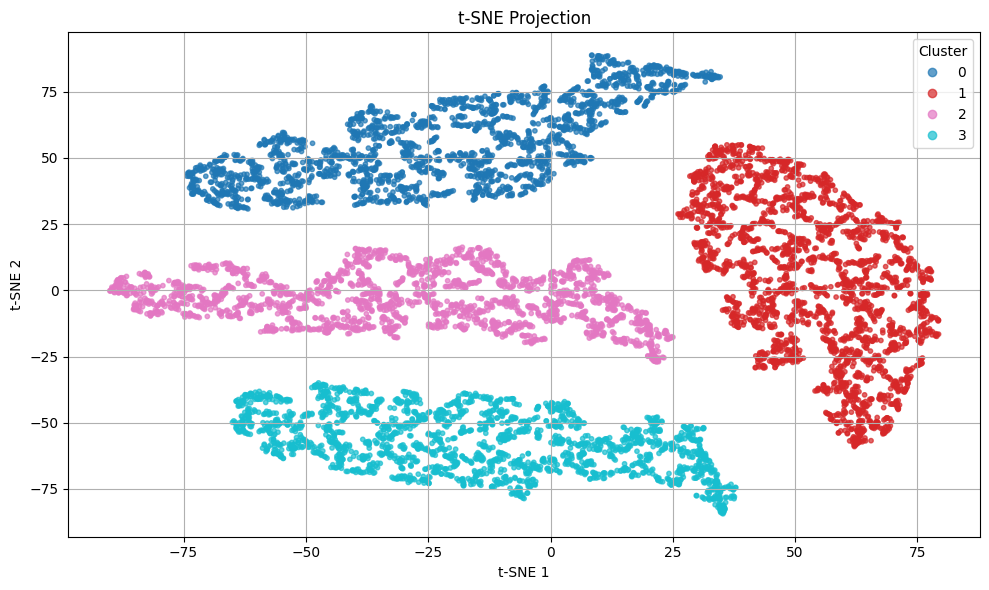

In [220]:
plot_tsne(scores_pca, labels=labels)

#### 🌐 t-SNE Visualization: Seasonal Cluster Patterns

This t-SNE projection is based on the following features:

- **Numerical**: `revenue`, `popularity`, `weighted_rating`  
- **Categorical (One-Hot)**: `winter`, `summer`, `fall`, `spring`

##### 🔎 Key Observation:

The plot reveals **four distinct clusters**, each corresponding to a **season** — as expected from the one-hot encoded seasonal features.

But more interestingly:

- **Three clusters** (likely **winter**, **spring**, and **fall**) are **elongated horizontally**, forming stretched bands across the x-axis.
- In contrast, **one cluster** (most likely **summer**) is **elongated vertically**, forming a tall column along the y-axis.

##### 🧠 Interpretation:

- Since all clusters are driven by season labels, their separation is expected.
- However, the **difference in shape orientation** hints at **varying distributions of the numeric features** within each season:
  - A **horizontal stretch** suggests more variance along `t-SNE 1`, which is likely aligned with a combination of `revenue`, `popularity`, or `weighted_rating`.
  - A **vertical stretch** suggests that in this season, movies share similar values on one t-SNE component but vary more on the other.

This might imply that:
- In **summer**, for instance, there’s a consistent trend in one dimension (e.g., similar popularity), but wide spread in another (e.g., diverse revenue).
- Other seasons may have more balanced or constrained variation across multiple features.

##### 📌 Takeaway:

Even though seasonal clusters are expected due to binary encoding, the **shape and orientation** of each cluster provide valuable insights about **intra-season variance** in movie features.  
This visualization suggests that while seasonal groups are dominant, their **internal structure still reflects underlying feature dynamics**.